In [1]:
import matplotlib.pyplot as plt 
import numpy as np

In [2]:
survey_list = np.array([ # name, solid angle surveyed in one pointing, fraction of time on-sky
    ['P. Horowitz & C. Sagan (1993)\n(wide-field transit survey)', 0.00005981154, 1], # on all the time, but not all-sky all the time
    #['Project Phoenix (2004)',],
    #['A. P. V. Siemion et al. (2013)',],
    ['G. R. Harp et al. (2016)\n(ATA search of HZ exoplanets)', 0.00149528511, 19000/(6.5*365*24)], # 19000 hr over 6.5 yr
    #['R. H. Gray & K. Mooley (2017)',],
    #['J. E. Enriquez et al. (2017)',],
    ['C. D. Tremblay & S. J. Tingay (2020)\n(MWA search of Vela region)', 0.12184, 17/(18*24)], # 17 hours over 18 days
    ['D. C. Price et al. (2020)\n(GBT+Parkes search of nearby stars)', 0.00000425327, 1044/(1177*24)], # 1044 hours over 1177 days
    #['M. A. Garrett & A. P. V. Siemion (2022)',],
    #['Y. Uno et al. (2023)',],
    ['C. Choza et al. (2024)\n(GBT search of nearby galaxies)', 0.00000425327, 229/(5*365*24)], # 229 hours over 5 years
    ['Galactic Radio Explorer (GReX)', 2.77, 1] # 4*np.pi at full deployment
])

omega_choza = 0.00000425327*97
omega_grex = 2.77 # 4*np.pi
lookback_time_choza = 300 # s
lookback_time_grex = 1*365*24*60*60 # s
dmax_choza = 9.010168103403985e+23
dmax_grex = 1e4 * 3.086e16
eirp_choza = 3.459096011436076e+24
eirp_grex = 8.5e24
bwmax_choza = 20000000
bwmax_grex = 20000000
ibw_choza = 9.6e9
ibw_grex = 188e6

In [3]:
coverage_fracs = survey_list[:,1].astype(float)*survey_list[:,2].astype(float)/4/np.pi
for i in range(6):
    print(survey_list[i,0], coverage_fracs[i]) # all sky all the time fraction

P. Horowitz & C. Sagan (1993)
(wide-field transit survey) 4.759651122469311e-06
G. R. Harp et al. (2016)
(ATA search of HZ exoplanets) 3.970546465732316e-05
C. D. Tremblay & S. J. Tingay (2020)
(MWA search of Vela region) 0.00038154450292520944
D. C. Price et al. (2020)
(GBT+Parkes search of nearby stars) 1.2509094774424069e-08
C. Choza et al. (2024)
(GBT search of nearby galaxies) 1.7695973557103042e-09
Galactic Radio Explorer (GReX) 0.22042959618227506


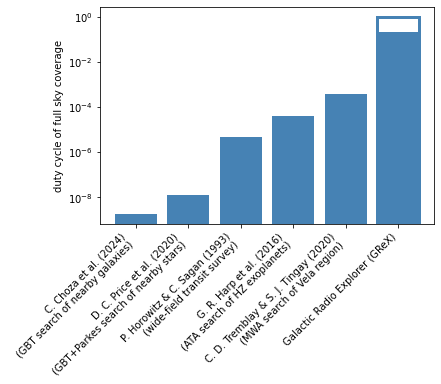

In [8]:
plt.bar(survey_list[:,0][np.argsort(coverage_fracs)], [0, 0, 0, 0, 0, 1], color='steelblue', edgecolor='steelblue', linewidth=3, fill=False)
plt.bar(survey_list[:,0][np.argsort(coverage_fracs)], np.sort(coverage_fracs), color='steelblue')
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.ylabel('duty cycle of full sky coverage')
plt.savefig('/home/benjb/nearby-stars/transmitter_rate_vs_EIRP/seti_limits_py3/survey_coverage_fraction.pdf', bbox_inches='tight')
plt.show()

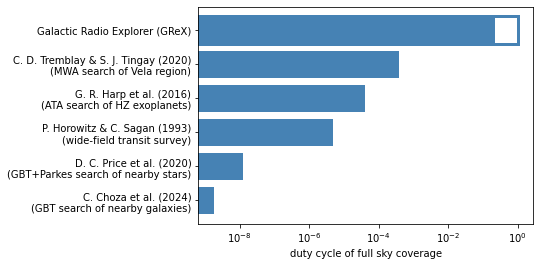

In [6]:
plt.barh(survey_list[:,0][np.argsort(coverage_fracs)], [0, 0, 0, 0, 0, 1], color='steelblue', edgecolor='steelblue', linewidth=3, fill=False)
plt.barh(survey_list[:,0][np.argsort(coverage_fracs)], np.sort(coverage_fracs), color='steelblue')
plt.xscale('log')
plt.yticks(rotation=0, ha='right')
plt.xlabel('duty cycle of full sky coverage')
plt.savefig('/home/benjb/nearby-stars/transmitter_rate_vs_EIRP/seti_limits_py3/survey_coverage_fraction_horizontal.pdf', bbox_inches='tight')
plt.show()

In [17]:
def haystack_fraction(solid_angle, d, bwt, ibw, tmax, eirpmin):
    return (solid_angle * d**5) * bwt * tmax * ibw / 5 / eirpmin / (6.4e116)

print(haystack_fraction(omega_choza, dmax_choza, bwmax_choza, ibw_choza, lookback_time_choza, eirp_choza))
print(haystack_fraction(omega_grex, dmax_grex, bwmax_grex, ibw_grex, lookback_time_grex, eirp_grex))
print(haystack_fraction(4*np.pi, dmax_grex, bwmax_grex, ibw_grex, lookback_time_grex, eirp_grex))
print(haystack_fraction(4*np.pi, dmax_grex, bwmax_grex, ibw_grex, lookback_time_grex, 3.710654243934994e+21))
print(haystack_fraction(3.2e-3*1327/692, 50*3.086e16, 20000000, (3.45-1.1)*10**9, 300, 2.1e12))

1.274879225593922e-06
3.3797527145142e-17
1.5332572272733534e-16
3.5122341169687865e-13
1.126144905895714e-22


['3.3797527145142e-17' '3.8e-19' '4.44e-19' '3.57e-20' '4.28e-18' '2e-16']


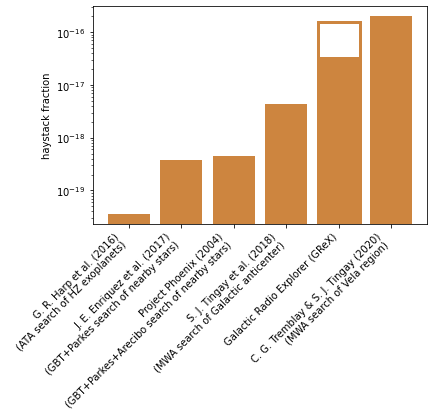

In [ ]:
haystack_frac = np.array([
    ['Galactic Radio Explorer (GReX)', 3.3797527145142e-17],
    ['J. E. Enriquez et al. (2017)\n(GBT+Parkes search of nearby stars)', 3.8e-19],
    #['A. P. V. Siemion et al. (2013)', 1.3e-19],
    ['Project Phoenix (2004)\n(GBT+Parkes+Arecibo search of nearby stars)', 44.4e-20],
    ['G. R. Harp et al. (2016)\n(ATA search of HZ exoplanets)', 35.7e-21],
    ['S. J. Tingay et al. (2018)\n(MWA search of Galactic anticenter)', 4.28e-18],
    ['C. G. Tremblay & S. J. Tingay (2020)\n(MWA search of Vela region)', 2e-16]
])
print(haystack_frac[:,1])

plt.bar(haystack_frac[:,0][np.argsort(haystack_frac[:,1].astype(float))], [0,0,0,0,1.5332572272733534e-16,0], edgecolor='peru', lw=3, fill=False)
plt.bar(haystack_frac[:,0][np.argsort(haystack_frac[:,1].astype(float))], np.sort(haystack_frac[:,1].astype(float)), color='peru')
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.ylabel('haystack fraction')
plt.savefig('/home/benjb/nearby-stars/transmitter_rate_vs_EIRP/seti_limits_py3/haystack_fraction.pdf', bbox_inches='tight')
plt.show()

['3.3797527145142e-17' '3.8e-19' '4.44e-19' '3.57e-20' '4.28e-18' '2e-16']


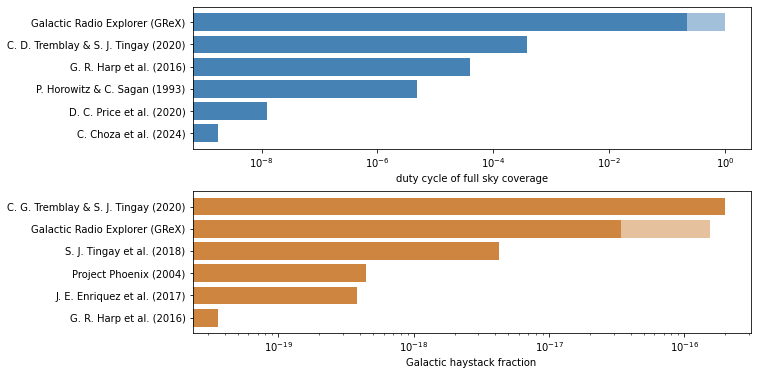

In [16]:
survey_list = np.array([ # name, solid angle surveyed in one pointing, fraction of time on-sky
    ['P. Horowitz & C. Sagan (1993)', 0.00005981154, 1], # on all the time, but not all-sky all the time
    #['Project Phoenix (2004)',],
    #['A. P. V. Siemion et al. (2013)',],
    ['G. R. Harp et al. (2016)', 0.00149528511, 19000/(6.5*365*24)], # 19000 hr over 6.5 yr
    #['R. H. Gray & K. Mooley (2017)',],
    #['J. E. Enriquez et al. (2017)',],
    ['C. D. Tremblay & S. J. Tingay (2020)', 0.12184, 17/(18*24)], # 17 hours over 18 days
    ['D. C. Price et al. (2020)', 0.00000425327, 1044/(1177*24)], # 1044 hours over 1177 days
    #['M. A. Garrett & A. P. V. Siemion (2022)',],
    #['Y. Uno et al. (2023)',],
    ['C. Choza et al. (2024)', 0.00000425327, 229/(5*365*24)], # 229 hours over 5 years
    ['Galactic Radio Explorer (GReX)', 2.77, 1] # 4*np.pi at full deployment
])

haystack_frac = np.array([
    ['Galactic Radio Explorer (GReX)', 3.3797527145142e-17],
    ['J. E. Enriquez et al. (2017)', 3.8e-19],
    #['A. P. V. Siemion et al. (2013)', 1.3e-19],
    ['Project Phoenix (2004)', 44.4e-20],
    ['G. R. Harp et al. (2016)', 35.7e-21],
    ['S. J. Tingay et al. (2018)', 4.28e-18],
    ['C. G. Tremblay & S. J. Tingay (2020)', 2e-16]
])
print(haystack_frac[:,1])

fig, ax = plt.subplots(2, 1, figsize=(10,6))

ax[0].barh(survey_list[:,0][np.argsort(coverage_fracs)], [0, 0, 0, 0, 0, 1], color='steelblue', alpha=0.5)
ax[0].barh(survey_list[:,0][np.argsort(coverage_fracs)], np.sort(coverage_fracs), color='steelblue')
ax[0].set_xscale('log')
#ax[0].set_yticks(rotation=0, ha='right')
ax[0].set_xlabel('duty cycle of full sky coverage')

ax[1].barh(haystack_frac[:,0][np.argsort(haystack_frac[:,1].astype(float))], [0,0,0,0,1.5332572272733534e-16,0], color='peru', alpha=0.5)
ax[1].barh(haystack_frac[:,0][np.argsort(haystack_frac[:,1].astype(float))], np.sort(haystack_frac[:,1].astype(float)), color='peru')
ax[1].set_xscale('log')
#ax[1].set_yticks(rotation=0, ha='right')
ax[1].set_xlabel('Galactic haystack fraction')
plt.subplots_adjust(hspace=0.3)
plt.savefig('/home/benjb/nearby-stars/transmitter_rate_vs_EIRP/seti_limits_py3/sky_coverage_and_haystack_fraction.pdf', bbox_inches='tight')
plt.show()